# 🔮 ProphetNet — Pipeline de Inferencia
**Procesamiento de Datos Secuenciales — Proyecto Final**

Este notebook implementa el pipeline completo de inferencia con ProphetNet:
1. Instalación de dependencias
2. Carga del modelo preentrenado
3. Preprocesamiento (tokenización)
4. Inferencia (generación de titulares)
5. Postprocesamiento
6. Métricas ROUGE
7. Visualización del mecanismo de atención (Q, K, V)
8. Interfaz interactiva con Streamlit

> ⚡ **Importante:** Ve a `Entorno de ejecución → Cambiar tipo de entorno de ejecución → GPU (T4)` antes de correr.

---
## 📦 Celda 1 — Instalación de dependencias

In [1]:
# Se instalan las librerías necesarias para el proyecto.
# transformers provee la implementación de ProphetNet de HuggingFace.
# torch es el framework de deep learning sobre el que corre el modelo.
# rouge-score permite calcular las métricas de evaluación de los titulares.
# sentencepiece es el tokenizador requerido internamente por ProphetNet.
# matplotlib y seaborn se usan para visualizar los mapas de atención.

!pip install transformers torch rouge-score sentencepiece matplotlib seaborn -q

print("✅ Dependencias instaladas correctamente.")

  Preparing metadata (setup.py) ... done
✅ Dependencias instaladas correctamente.


---
## 📚 Celda 2 — Importaciones

In [2]:
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ProphetNetForConditionalGeneration es la clase que contiene la arquitectura
# encoder-decoder completa con el n-stream decoder innovador del modelo.
# ProphetNetTokenizer convierte el texto en secuencias de tokens (números)
# que el modelo puede procesar, y también decodifica el output de vuelta a texto.
from transformers import ProphetNetForConditionalGeneration, ProphetNetTokenizer

# rouge_scorer implementa las métricas ROUGE-1, ROUGE-2 y ROUGE-L,
# que miden la similitud entre el titular generado y el titular real.
from rouge_score import rouge_scorer

# Se verifica si hay GPU disponible en el entorno de ejecución.
# Con GPU el modelo corre en segundos; sin ella puede tardar hasta 60 segundos.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Dispositivo detectado: {device}")

if device.type == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memoria disponible: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("   ⚠️ No se detectó GPU. La inferencia será más lenta pero funcionará igual.")

🖥️  Dispositivo detectado: cuda
   GPU: Tesla T4
   Memoria disponible: 15.6 GB


---
## 🤖 Celda 3 — Carga del modelo y tokenizer

In [3]:
# Se utiliza la versión fine-tuneada del modelo sobre el dataset CNN/DailyMail,
# que fue entrenada específicamente para la tarea de headline generation.
# Esta versión produce resultados significativamente mejores que el modelo base.
MODEL_NAME = "microsoft/prophetnet-large-uncased-cnndm"

print("⏳ Cargando tokenizer...")
# El tokenizer se descarga desde HuggingFace Hub la primera vez y queda en caché.
# Convierte texto a input_ids (secuencia de enteros) y viceversa.
tokenizer = ProphetNetTokenizer.from_pretrained(MODEL_NAME)
print("✅ Tokenizer listo.")

print("\n⏳ Cargando modelo (puede tardar 2-3 minutos la primera vez)...")
# Se descargan los pesos preentrenados (~1.57 GB) desde HuggingFace.
# En sesiones posteriores el modelo se carga desde caché sin descargar.
model = ProphetNetForConditionalGeneration.from_pretrained(MODEL_NAME)

# El modelo se mueve al dispositivo disponible (GPU o CPU).
model = model.to(device)

# El modo evaluación desactiva el dropout, una técnica que apaga neuronas
# aleatoriamente durante el entrenamiento para evitar sobreajuste.
# En inferencia el dropout debe estar desactivado para resultados deterministas.
model.eval()

print(f"✅ Modelo cargado en {device}.")
print(f"\n📊 Información del modelo:")
print(f"   Parámetros totales: {sum(p.numel() for p in model.parameters()):,}")
print(f"   Capas del encoder: {model.config.num_encoder_layers}")
print(f"   Capas del decoder: {model.config.num_decoder_layers}")
print(f"   Dimensión oculta (d_model): {model.config.hidden_size}")
print(f"   Cabezas de atención: {model.config.num_attention_heads}")
print(f"   N-gram del decoder (n-stream): {model.config.ngram}")
print(f"   Vocabulario: {model.config.vocab_size:,} tokens")

⏳ Cargando tokenizer...


tokenizer_config.json:   0%|          | 0.00/256 [00:00<?, ?B/s]

prophetnet.tokenizer: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

✅ Tokenizer listo.

⏳ Cargando modelo (puede tardar 2-3 minutos la primera vez)...


...

model.safetensors:   0%|          | 0.00/1.57G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/539 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie prophetnet.word_embeddings.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie prophetnet.word_embeddings.weight to prophetnet.encoder.word_embeddings.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie prophetnet.word_embeddings.weight to prophetnet.decoder.word_embeddings.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/174 [00:00<?, ?B/s]

✅ Modelo cargado en cuda.

📊 Información del modelo:
   Parámetros totales: 485,085,184
   Capas del encoder: 12
   Capas del decoder: 12
   Dimensión oculta (d_model): 1024
   Cabezas de atención: 16
   N-gram del decoder (n-stream): 2
   Vocabulario: 30,522 tokens


---
## ✏️ Celda 4 — Textos de ejemplo para inferencia

In [4]:
# Se definen cinco artículos de noticias reales en inglés junto con sus titulares
# originales (ground truth). Esta estructura permite comparar cuantitativamente
# el titular generado por el modelo contra el titular real usando métricas ROUGE.
# Los textos están en minúsculas porque el modelo fue entrenado con texto uncased.

ejemplos = [
    {
        "articulo": "the us state department said wednesday it had received no formal word from bolivia "
                    "that it was expelling the us ambassador there but said the charges made against him "
                    "are baseless and that he enjoys the full confidence of the secretary of state.",
        "titular_real": "us rejects charges against its ambassador in bolivia"
    },
    {
        "articulo": "scientists have discovered a new species of dinosaur in argentina that they believe "
                    "is one of the largest creatures ever to have walked the earth. the titanosaur, "
                    "which lived about 100 million years ago, is estimated to have weighed 70 tons and "
                    "measured 40 meters from head to tail.",
        "titular_real": "scientists discover one of the largest dinosaurs ever found in argentina"
    },
    {
        "articulo": "apple has announced its quarterly earnings, reporting record revenue of 90 billion dollars "
                    "driven by strong iphone sales and growth in its services division. the company also "
                    "announced a new stock buyback program worth 90 billion dollars and increased its "
                    "quarterly dividend by four percent.",
        "titular_real": "apple reports record quarterly revenue driven by iphone and services growth"
    },
    {
        "articulo": "nasa has confirmed that its perseverance rover has successfully collected its first rock "
                    "sample from the surface of mars. the sample, extracted from a rock called rochette, "
                    "will eventually be returned to earth for detailed scientific analysis. scientists hope "
                    "the samples will help answer whether life ever existed on mars.",
        "titular_real": "nasa perseverance rover collects first mars rock sample"
    },
    {
        "articulo": "the world health organization declared a global health emergency on thursday as a new "
                    "respiratory virus continues to spread across multiple continents. health officials "
                    "urged governments to increase surveillance and strengthen their health systems "
                    "while researchers race to develop vaccines and treatments.",
        "titular_real": "who declares global health emergency over new respiratory virus"
    },
]

print(f"✅ {len(ejemplos)} artículos listos para inferencia.")
print("\n📰 Ejemplo 1 (preview):")
print(f"   Artículo: {ejemplos[0]['articulo'][:80]}...")
print(f"   Titular real: {ejemplos[0]['titular_real']}")

✅ 5 artículos listos para inferencia.

📰 Ejemplo 1 (preview):
   Artículo: the us state department said wednesday it had received no formal word from boliv...
   Titular real: us rejects charges against its ambassador in bolivia


---
## ⚙️ Celda 5 — Función de inferencia

In [5]:
def generar_titular(articulo, num_beams=4, max_length=60, min_length=8, no_repeat_ngram_size=3):
    """
    Implementa el pipeline completo de inferencia en tres pasos:
    preprocesamiento, inferencia y postprocesamiento.
    """

    # PASO 1 — PREPROCESAMIENTO
    # El tokenizer convierte el texto a input_ids (secuencia de enteros)
    # y un attention_mask que indica qué posiciones son tokens reales (1)
    # y cuáles son padding (0). El modelo usa esta máscara para ignorar
    # el padding en los cálculos de atención.
    # El texto se convierte a minúsculas porque el modelo es 'uncased':
    # fue entrenado sin distinción entre mayúsculas y minúsculas.
    inputs = tokenizer(
        articulo.lower(),
        return_tensors="pt",
        truncation=True,
        max_length=512  # límite máximo del encoder de ProphetNet
    )
    input_ids = inputs["input_ids"].to(device)
    attention_mask = inputs["attention_mask"].to(device)

    # PASO 2 — INFERENCIA
    # torch.no_grad() desactiva el cálculo de gradientes, que solo se necesita
    # durante el entrenamiento. En inferencia esto ahorra memoria y acelera el proceso.
    # model.generate() ejecuta el decoder de forma autoregresiva:
    # genera un token, lo agrega a la secuencia, genera el siguiente, y así.
    # Beam search mantiene las num_beams hipótesis más probables en paralelo
    # y al final retorna la secuencia con mayor probabilidad acumulada.
    with torch.no_grad():
        output_ids = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            num_beams=num_beams,
            max_length=max_length,
            min_length=min_length,
            no_repeat_ngram_size=no_repeat_ngram_size,  # penaliza repeticiones
            early_stopping=True  # detiene la generación cuando todos los beams producen [EOS]
        )

    # PASO 3 — POSTPROCESAMIENTO
    # El decoder produjo una secuencia de enteros (output_ids).
    # El tokenizer los convierte de vuelta a texto legible.
    # skip_special_tokens=True elimina [PAD], [SEP], [CLS] del resultado final.
    titular = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return titular, input_ids


print("✅ Función de inferencia definida.")
print("\n🧪 Probando con el ejemplo 1...")

titular_prueba, _ = generar_titular(ejemplos[0]["articulo"])
print(f"   Artículo:     {ejemplos[0]['articulo'][:70]}...")
print(f"   Titular real: {ejemplos[0]['titular_real']}")
print(f"   ProphetNet:   {titular_prueba}")

✅ Función de inferencia definida.

🧪 Probando con el ejemplo 1...
   Artículo:     the us state department said wednesday it had received no formal word ...
   Titular real: us rejects charges against its ambassador in bolivia
   ProphetNet:   the us state department said it had received no formal word from bolivia that it was expelling the us ambassador. it said the charges made against him are baseless.


---
## 🚀 Celda 6 — Inferencia sobre todos los ejemplos

In [6]:
# Se ejecuta el pipeline de inferencia sobre los cinco artículos definidos.
# Los resultados se almacenan en la lista 'resultados' para ser usados
# posteriormente en el cálculo de métricas ROUGE y en la visualización.

print("="*70)
print("RESULTADOS DE INFERENCIA — ProphetNet")
print("="*70)

resultados = []

for i, ejemplo in enumerate(ejemplos):
    print(f"\n📰 Ejemplo {i+1}")
    print(f"   Artículo:     {ejemplo['articulo'][:80]}...")

    titular_generado, _ = generar_titular(ejemplo["articulo"])

    print(f"   Titular real: {ejemplo['titular_real']}")
    print(f"   ProphetNet:   {titular_generado}")

    resultados.append({
        "articulo": ejemplo["articulo"],
        "titular_real": ejemplo["titular_real"],
        "titular_generado": titular_generado
    })

print("\n" + "="*70)
print(f"✅ Inferencia completada para {len(ejemplos)} artículos.")

RESULTADOS DE INFERENCIA — ProphetNet

📰 Ejemplo 1
   Artículo:     the us state department said wednesday it had received no formal word from boliv...
   Titular real: us rejects charges against its ambassador in bolivia
   ProphetNet:   the us state department said it had received no formal word from bolivia that it was expelling the us ambassador. it said the charges made against him are baseless.

📰 Ejemplo 2
   Artículo:     scientists have discovered a new species of dinosaur in argentina that they beli...
   Titular real: scientists discover one of the largest dinosaurs ever found in argentina
   ProphetNet:   scientists have discovered a new species of dinosaur in argentina. the titanosaur is estimated to have weighed 70 tons and measured 40 meters from head to tail.

📰 Ejemplo 3
   Artículo:     apple has announced its quarterly earnings, reporting record revenue of 90 billi...
   Titular real: apple reports record quarterly revenue driven by iphone and services growth
   Prop

---
## 📊 Celda 7 — Métricas ROUGE

In [7]:
# ROUGE (Recall-Oriented Understudy for Gisting Evaluation) es la métrica
# estándar para evaluar modelos de generación de resúmenes.
# ROUGE-1 mide el overlap de palabras individuales (unigramas).
# ROUGE-2 mide el overlap de pares de palabras consecutivas (bigramas).
# ROUGE-L mide la subsecuencia común más larga entre el texto generado y el real.
# use_stemmer=True reduce las palabras a su raíz antes de comparar,
# de modo que 'running' y 'run' se tratan como equivalentes.

scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

r1_scores, r2_scores, rL_scores = [], [], []

print("="*70)
print("MÉTRICAS ROUGE POR EJEMPLO")
print("="*70)
print(f"{'Ej':<5} {'ROUGE-1':>10} {'ROUGE-2':>10} {'ROUGE-L':>10}")
print("-"*40)

for i, r in enumerate(resultados):
    # Se compara el titular generado contra el titular real.
    # .fmeasure es el F1-score, que balancea precisión y recall.
    scores = scorer.score(
        target=r["titular_real"],
        prediction=r["titular_generado"]
    )
    r1 = scores["rouge1"].fmeasure
    r2 = scores["rouge2"].fmeasure
    rL = scores["rougeL"].fmeasure

    r1_scores.append(r1)
    r2_scores.append(r2)
    rL_scores.append(rL)

    print(f"{i+1:<5} {r1:>10.4f} {r2:>10.4f} {rL:>10.4f}")

print("-"*40)
print(f"{'Prom':<5} {np.mean(r1_scores):>10.4f} {np.mean(r2_scores):>10.4f} {np.mean(rL_scores):>10.4f}")
print("="*70)
print(f"\n📈 Resumen:")
print(f"   ROUGE-1 promedio: {np.mean(r1_scores):.4f}")
print(f"   ROUGE-2 promedio: {np.mean(r2_scores):.4f}")
print(f"   ROUGE-L promedio: {np.mean(rL_scores):.4f}")

MÉTRICAS ROUGE POR EJEMPLO
Ej       ROUGE-1    ROUGE-2    ROUGE-L
----------------------------------------
1         0.2703     0.0000     0.1622
2         0.3684     0.0556     0.3158
3         0.1935     0.0000     0.1935
4         0.4444     0.1176     0.3889
5         0.3784     0.2286     0.3784
----------------------------------------
Prom      0.3310     0.0804     0.2878

📈 Resumen:
   ROUGE-1 promedio: 0.3310
   ROUGE-2 promedio: 0.0804
   ROUGE-L promedio: 0.2878


---
## 📊 Celda 8 — Gráfica de métricas ROUGE

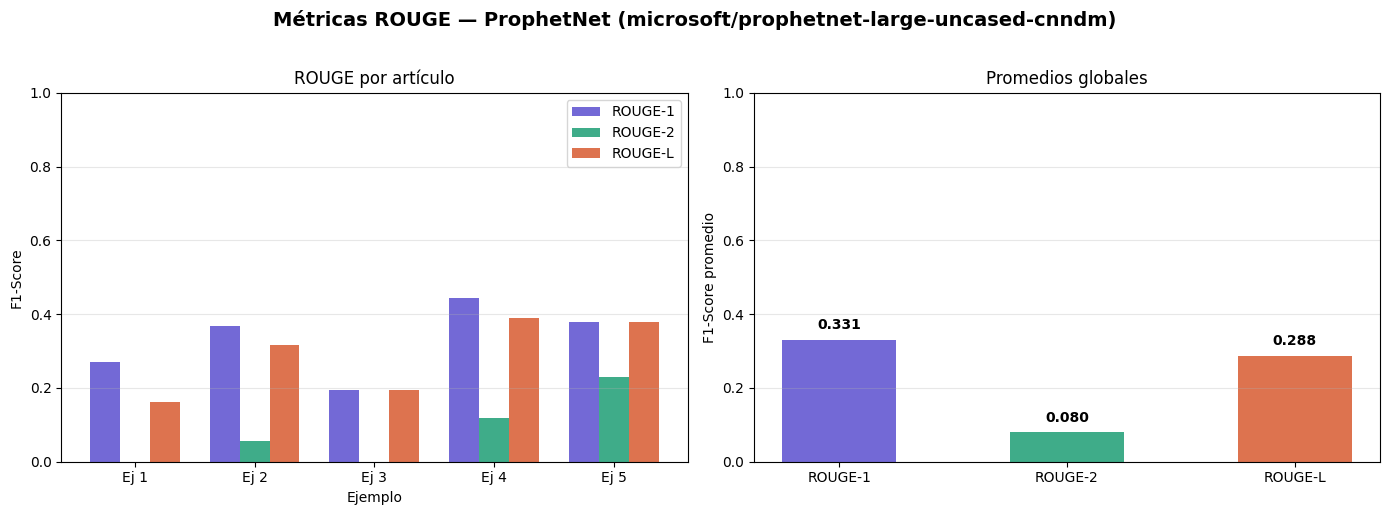

💾 Gráfica guardada como rouge_metrics.png


In [8]:
# Se genera una visualización de las métricas ROUGE para su inclusión en el README.
# El panel izquierdo muestra las tres métricas por artículo individualmente.
# El panel derecho muestra los promedios globales del modelo.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Métricas ROUGE — ProphetNet (microsoft/prophetnet-large-uncased-cnndm)",
             fontsize=14, fontweight="bold", y=1.02)

x = np.arange(len(resultados))
width = 0.25
labels = [f"Ej {i+1}" for i in range(len(resultados))]

axes[0].bar(x - width, r1_scores, width, label="ROUGE-1", color="#5B4FCF", alpha=0.85)
axes[0].bar(x,         r2_scores, width, label="ROUGE-2", color="#1D9E75", alpha=0.85)
axes[0].bar(x + width, rL_scores, width, label="ROUGE-L", color="#D85A30", alpha=0.85)
axes[0].set_xlabel("Ejemplo")
axes[0].set_ylabel("F1-Score")
axes[0].set_title("ROUGE por artículo")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylim(0, 1.0)
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

metrics = ["ROUGE-1", "ROUGE-2", "ROUGE-L"]
promedios = [np.mean(r1_scores), np.mean(r2_scores), np.mean(rL_scores)]
colors = ["#5B4FCF", "#1D9E75", "#D85A30"]

bars = axes[1].bar(metrics, promedios, color=colors, alpha=0.85, width=0.5)
axes[1].set_ylabel("F1-Score promedio")
axes[1].set_title("Promedios globales")
axes[1].set_ylim(0, 1.0)
axes[1].grid(axis="y", alpha=0.3)

for bar, val in zip(bars, promedios):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"{val:.3f}", ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.savefig("rouge_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Gráfica guardada como rouge_metrics.png")

---
## 🔬 Celda 9 — Extracción del mecanismo de atención (Q, K, V)

In [9]:
def extraer_atencion(articulo, titular_generado):
    """
    Extrae los pesos de cross-attention entre el decoder y el encoder.
    Estos pesos representan el resultado de softmax(Q·Kᵀ / √d),
    es decir, cuánta atención puso cada token generado en cada token
    del artículo original durante la generación del titular.
    Se retorna la última capa del decoder, promediada entre las 16 cabezas.
    """

    # El artículo se tokeniza como entrada del encoder.
    inputs = tokenizer(
        articulo.lower(),
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(device)

    # El titular generado se tokeniza como entrada del decoder.
    # Se usa el mismo tokenizer sin context manager especial
    # porque en versiones recientes de transformers ya no es necesario.
    labels = tokenizer(
        titular_generado,
        return_tensors="pt",
        truncation=True,
        max_length=128
    ).input_ids.to(device)

    # output_attentions=True le indica al modelo que devuelva los pesos
    # de atención de todas las capas, además de las salidas normales.
    with torch.no_grad():
        outputs = model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            decoder_input_ids=labels,
            output_attentions=True
        )

    # outputs.cross_attentions es una tupla con un tensor por capa del decoder.
    # Cada tensor tiene forma (batch, num_heads, seq_decoder, seq_encoder).
    # Se toma la última capa (índice -1) que contiene la representación más rica,
    # se elimina la dimensión de batch con squeeze, y se promedian las 16 cabezas.
    cross_attn = outputs.cross_attentions[-1]
    cross_attn = cross_attn.squeeze(0).mean(dim=0).cpu().numpy()

    # ProphetNet devuelve los pesos en log-space (log-softmax).
    # Se aplica np.exp() para convertirlos a probabilidades reales entre 0 y 1,
    # y luego se normalizan para que cada fila sume exactamente 1.
    cross_attn = np.exp(cross_attn)
    cross_attn = cross_attn / cross_attn.sum(axis=-1, keepdims=True)

    # Se convierten los IDs numéricos a tokens de texto legibles.
    tokens_entrada = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    tokens_salida  = tokenizer.convert_ids_to_tokens(labels[0])

    # Se eliminan los tokens especiales de padding y separadores
    # para que el heatmap solo muestre tokens de contenido real.
    tokens_entrada = [t for t in tokens_entrada if t not in ["[PAD]", "[CLS]"]]
    tokens_salida  = [t for t in tokens_salida  if t not in ["[PAD]", "[SEP]"]]

    # La matriz de atención se recorta al tamaño de los tokens limpios.
    cross_attn = cross_attn[:len(tokens_salida), :len(tokens_entrada)]

    return cross_attn, tokens_entrada, tokens_salida


print("✅ Función corregida definida.")
print("\n⏳ Extrayendo pesos de atención del ejemplo 1...")

attn, tok_in, tok_out = extraer_atencion(
    resultados[0]["articulo"],
    resultados[0]["titular_generado"]
)

print(f"✅ Atención extraída.")
print(f"   Tokens de entrada: {len(tok_in)}")
print(f"   Tokens de salida:  {len(tok_out)}")
print(f"   Forma de la matriz: {attn.shape}")

✅ Función corregida definida.

⏳ Extrayendo pesos de atención del ejemplo 1...
✅ Atención extraída.
   Tokens de entrada: 48
   Tokens de salida:  34
   Forma de la matriz: (34, 48)


---
## 🔥 Celda 10 — Heatmap de cross-attention

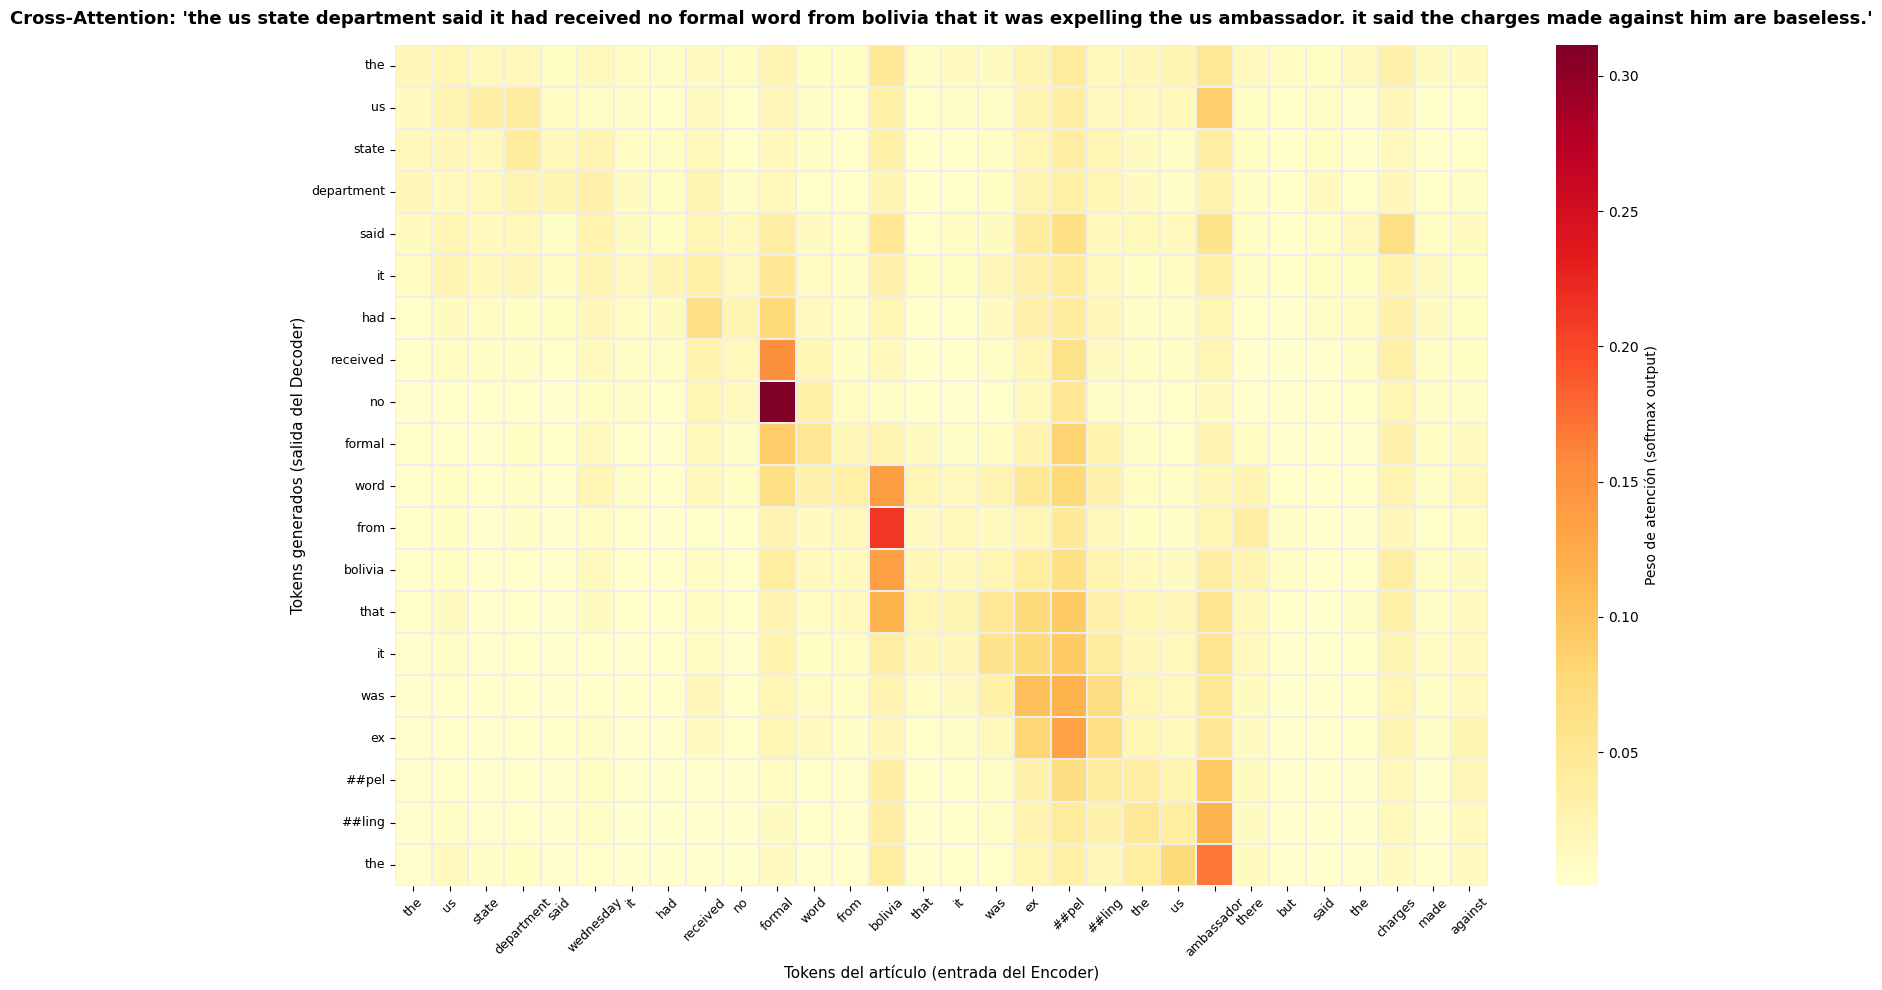

💾 Heatmap guardado como attention_heatmap.png


In [10]:
def graficar_atencion(attn_matrix, tokens_entrada, tokens_salida, titulo="Cross-Attention Heatmap"):
    """
    Genera un heatmap de los pesos de cross-attention.
    El eje X representa los tokens del artículo (encoder).
    El eje Y representa los tokens del titular generado (decoder).
    El color codifica la intensidad de atención: más rojo = más atención.
    Cada celda (i,j) muestra cuánta atención prestó el token i del titular
    al token j del artículo durante la generación.
    """

    # Se limita el número de tokens mostrados para mantener el gráfico legible.
    max_in  = min(30, len(tokens_entrada))
    max_out = min(20, len(tokens_salida))

    attn_plot = attn_matrix[:max_out, :max_in]
    toks_in   = tokens_entrada[:max_in]
    toks_out  = tokens_salida[:max_out]

    fig, ax = plt.subplots(figsize=(max(12, max_in * 0.5), max(6, max_out * 0.5)))

    # El colormap YlOrRd va de amarillo (baja atención) a rojo (alta atención),
    # lo que facilita la identificación visual de los tokens más relevantes.
    sns.heatmap(
        attn_plot,
        ax=ax,
        xticklabels=toks_in,
        yticklabels=toks_out,
        cmap="YlOrRd",
        linewidths=0.3,
        linecolor="#eeeeee",
        annot=False,
        cbar_kws={"label": "Peso de atención (softmax output)"}
    )

    ax.set_title(titulo, fontsize=13, fontweight="bold", pad=15)
    ax.set_xlabel("Tokens del artículo (entrada del Encoder)", fontsize=11)
    ax.set_ylabel("Tokens generados (salida del Decoder)", fontsize=11)
    ax.tick_params(axis="x", rotation=45, labelsize=9)
    ax.tick_params(axis="y", rotation=0,  labelsize=9)

    plt.tight_layout()
    plt.savefig("attention_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("💾 Heatmap guardado como attention_heatmap.png")


graficar_atencion(
    attn, tok_in, tok_out,
    titulo=f"Cross-Attention: '{resultados[0]['titular_generado']}'"
)

---
## 🔎 Celda 11 — Análisis de atención por token generado

In [11]:
def analizar_atencion_por_token(attn_matrix, tokens_entrada, tokens_salida, top_k=3):
    """
    Para cada token generado, se identifican los top_k tokens del artículo
    que recibieron mayor peso de atención. Esto ilustra concretamente cómo
    funciona el mecanismo Q/K/V: el Query de cada token generado (decoder)
    busca los Keys más similares en el encoder y pondera sus Values.
    El token con mayor peso es aquel cuyo Key resultó más compatible
    con el Query del token que se estaba generando.
    """
    print("="*65)
    print("ANÁLISIS DE ATENCIÓN POR TOKEN GENERADO")
    print(f"(Top-{top_k} tokens del artículo con más atención)")
    print("="*65)

    max_out = min(len(tokens_salida), attn_matrix.shape[0])
    max_in  = min(len(tokens_entrada), attn_matrix.shape[1])

    for i in range(max_out):
        pesos = attn_matrix[i, :max_in]
        top_indices = np.argsort(pesos)[::-1][:top_k]
        token_out = tokens_salida[i]
        top_tokens = [(tokens_entrada[j], pesos[j]) for j in top_indices]

        print(f"\n  Token generado [{i+1}]: '{token_out}'")
        print(f"  Más atención en:")
        for tok, peso in top_tokens:
            # La longitud de la barra es proporcional al peso de atención.
            barra = "█" * int(peso * 30)
            print(f"    '{tok}': {peso:.3f}  {barra}")

    print("\n" + "="*65)


analizar_atencion_por_token(attn, tok_in, tok_out, top_k=3)

ANÁLISIS DE ATENCIÓN POR TOKEN GENERADO
(Top-3 tokens del artículo con más atención)

  Token generado [1]: 'the'
  Más atención en:
    '.': 0.062  █
    'and': 0.062  █
    'the': 0.061  █

  Token generado [2]: 'us'
  Más atención en:
    '.': 0.151  ████
    'and': 0.145  ████
    'the': 0.142  ████

  Token generado [3]: 'state'
  Más atención en:
    '.': 0.167  ████
    'and': 0.160  ████
    'the': 0.156  ████

  Token generado [4]: 'department'
  Más atención en:
    '.': 0.168  █████
    'and': 0.162  ████
    'the': 0.158  ████

  Token generado [5]: 'said'
  Más atención en:
    '.': 0.091  ██
    'and': 0.088  ██
    'the': 0.086  ██

  Token generado [6]: 'it'
  Más atención en:
    '.': 0.120  ███
    'and': 0.115  ███
    'the': 0.113  ███

  Token generado [7]: 'had'
  Más atención en:
    '.': 0.133  ████
    'and': 0.128  ███
    'the': 0.125  ███

  Token generado [8]: 'received'
  Más atención en:
    'formal': 0.153  ████
    '.': 0.141  ████
    'and': 0.136  ███

---
## 🎯 Celda 12 — Prueba personalizada

📰 Artículo:
   the amazon rainforest, often referred to as the lungs of the earth, is losing approximately 10,000 square kilometers of forest per year due to deforestation. scientists warn that if current trends continue, the ecosystem could reach a tipping point within the next decade, causing irreversible damage to global climate patterns and biodiversity.

🔮 Titular generado por ProphetNet:
   the amazon rainforest is losing 10, 000 square kilometers of forest per year. deforestation is causing irreversible damage to global climate patterns


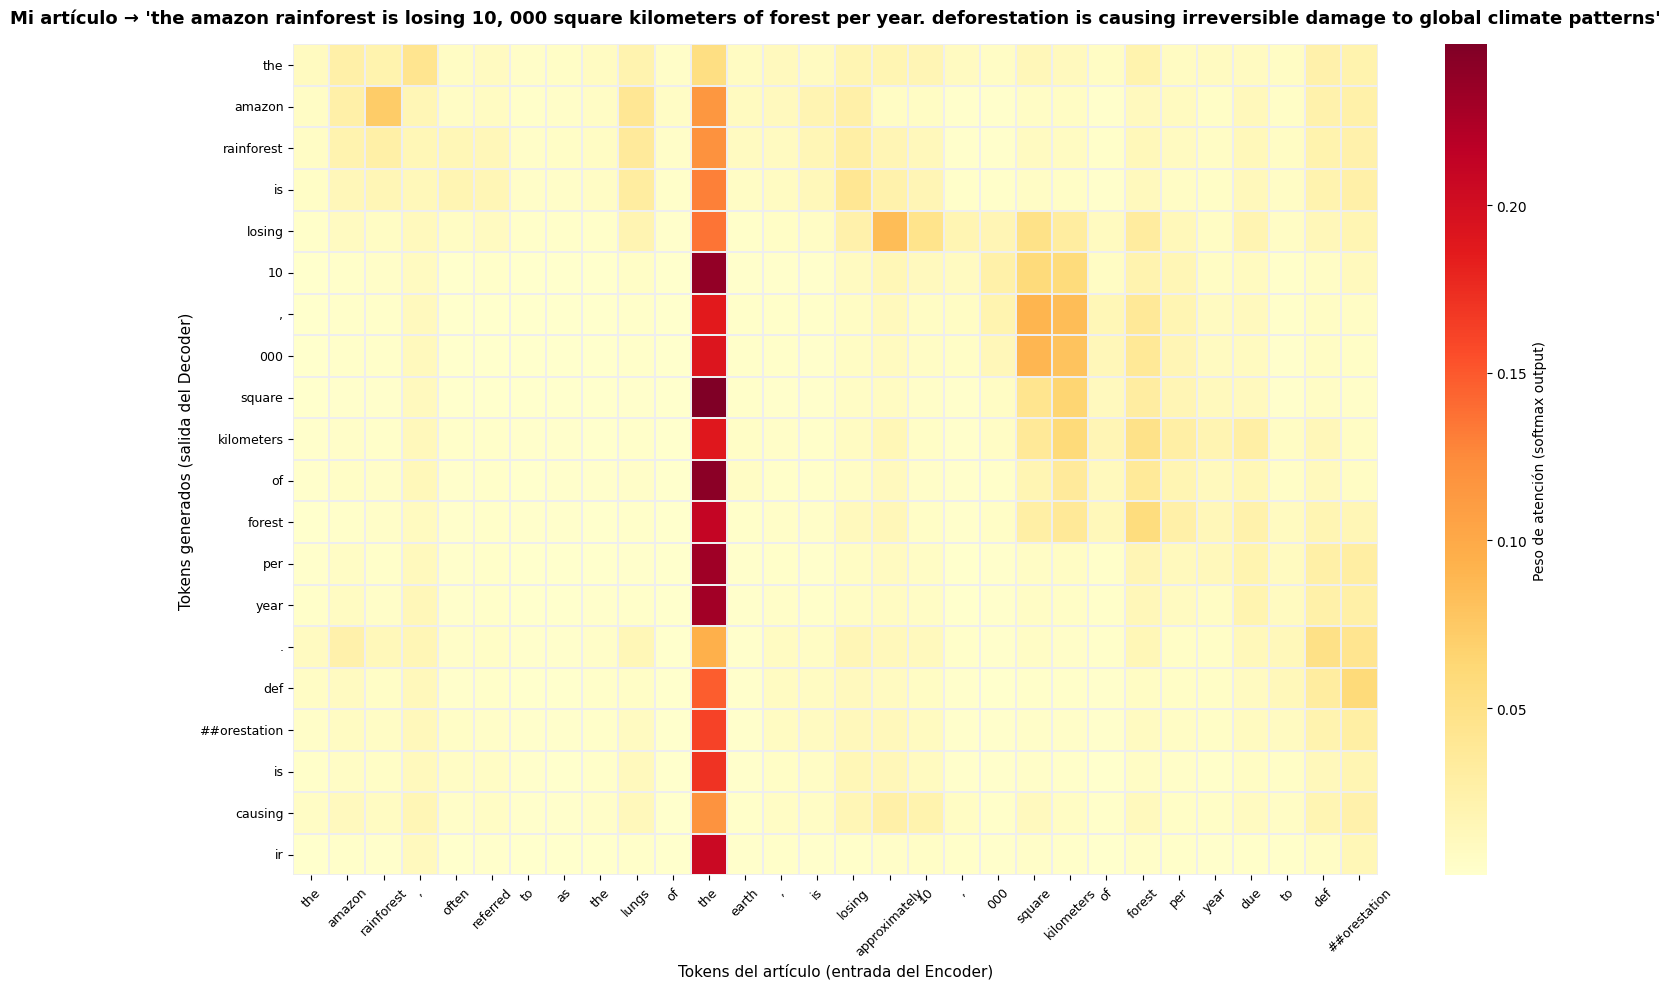

💾 Heatmap guardado como attention_heatmap.png


In [12]:
# Se define un artículo personalizado para demostrar la generalización del modelo.
# El texto se convierte a minúsculas con .lower() porque el modelo fue entrenado
# con texto en minúsculas (arquitectura 'uncased').
# max_length=30 limita el titular a un tamaño apropiado para un headline,
# evitando que el modelo repita fragmentos del artículo original.

mi_articulo = """
The amazon rainforest, often referred to as the lungs of the earth, is losing
approximately 10,000 square kilometers of forest per year due to deforestation.
Scientists warn that if current trends continue, the ecosystem could reach a tipping
point within the next decade, causing irreversible damage to global climate patterns
and biodiversity.
"""

mi_articulo = " ".join(mi_articulo.split()).lower()

print("📰 Artículo:")
print(f"   {mi_articulo}")

titular_mio, _ = generar_titular(mi_articulo, max_length=30, min_length=8)
print(f"\n🔮 Titular generado por ProphetNet:")
print(f"   {titular_mio}")

attn_mia, tok_in_mio, tok_out_mio = extraer_atencion(mi_articulo, titular_mio)
graficar_atencion(
    attn_mia, tok_in_mio, tok_out_mio,
    titulo=f"Mi artículo → '{titular_mio}'"
)